In [15]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics, model_selection

In [16]:
X, y = datasets.load_linnerud(return_X_y=True)
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (20, 3)
y shape: (20, 3)


In [17]:
print('X (first 5):', X[:5])
print('y (first 5):', y[:5])

X (first 5): [[  5. 162.  60.]
 [  2. 110.  60.]
 [ 12. 101. 101.]
 [ 12. 105.  37.]
 [ 13. 155.  58.]]
y (first 5): [[191.  36.  50.]
 [189.  37.  52.]
 [193.  38.  58.]
 [162.  35.  62.]
 [189.  35.  46.]]


### Find best alpha using cross-validation
The dataset only has 20 samples, so a single train/test split is unreliable.
Cross-validation gives a more stable estimate.

In [18]:
best_alpha = None
best_score = -np.inf

for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = linear_model.Ridge(alpha=alpha)
    scores = model_selection.cross_val_score(model, X, y, cv=5, scoring='r2')
    mean_score = scores.mean()
    print(f'alpha={alpha}: R²={mean_score:.3f} ± {scores.std():.3f}')
    if mean_score > best_score:
        best_score = mean_score
        best_alpha = alpha

print(f'\nBest alpha: {best_alpha}, Best R²: {best_score:.3f}')

alpha=0.01: R²=-4.731 ± 7.265
alpha=0.1: R²=-4.731 ± 7.264
alpha=1.0: R²=-4.725 ± 7.260
alpha=10.0: R²=-4.675 ± 7.216
alpha=100.0: R²=-4.327 ± 6.862

Best alpha: 100.0, Best R²: -4.327


### Train final model with best alpha and evaluate per output

In [19]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.33, random_state=42)

best_model = linear_model.Ridge(alpha=best_alpha)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

for i, label in enumerate(['Weight', 'Waist', 'Pulse']):
    r2  = metrics.r2_score(y_test[:, i], y_pred[:, i])
    mae = metrics.mean_absolute_error(y_test[:, i], y_pred[:, i])
    print(f'{label}: R²={r2:.3f}, MAE={mae:.3f}')

Weight: R²=-2.019, MAE=20.092
Waist: R²=0.493, MAE=1.096
Pulse: R²=-0.181, MAE=7.210


### Actual vs Predicted — one plot per target

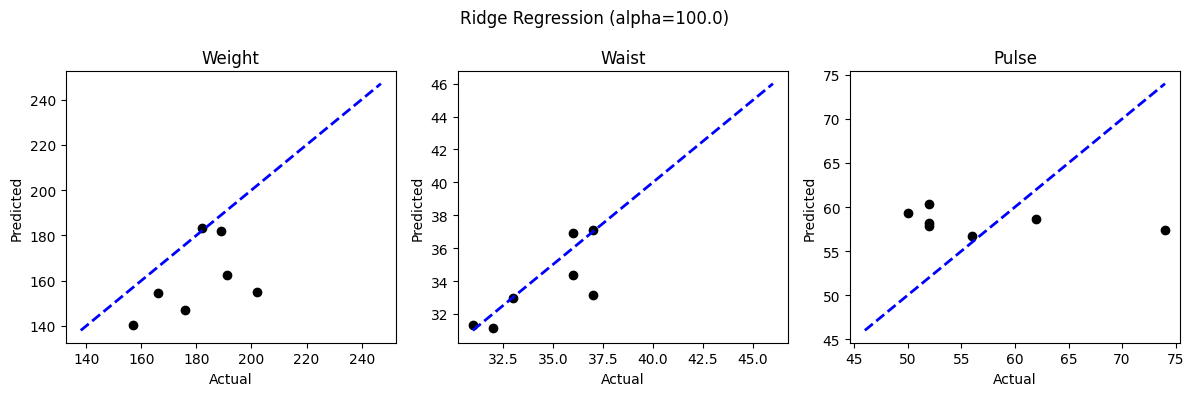

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, (ax, label) in enumerate(zip(axes, ['Weight', 'Waist', 'Pulse'])):
    ax.scatter(y_test[:, i], y_pred[:, i], color='black')
    ax.plot([y[:, i].min(), y[:, i].max()], [y[:, i].min(), y[:, i].max()], 'b--', lw=2)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(label)

plt.suptitle(f'Ridge Regression (alpha={best_alpha})')
plt.tight_layout()
plt.show()